# Q1

   model         param  value      mmd2
0   hist          bins  10.00  0.004375
1   hist          bins  20.00  0.000622
2   hist          bins  40.00 -0.000467
3    gmm  n_components   1.00  0.006917
4    gmm  n_components   2.00  0.006791
5    gmm  n_components   5.00  0.000317
6    kde     bandwidth   0.02 -0.000326
7    kde     bandwidth   0.05  0.000008
8    kde     bandwidth   0.10  0.000889
9  gauss          none   0.00  0.008077


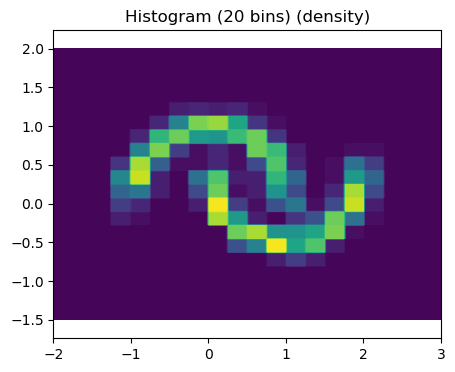

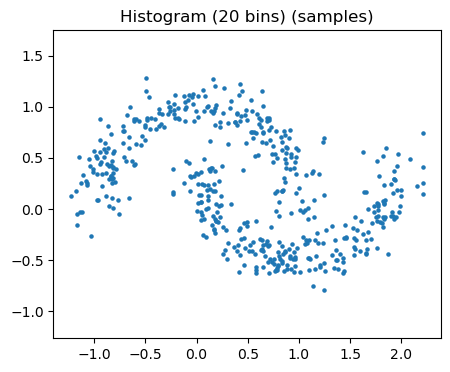

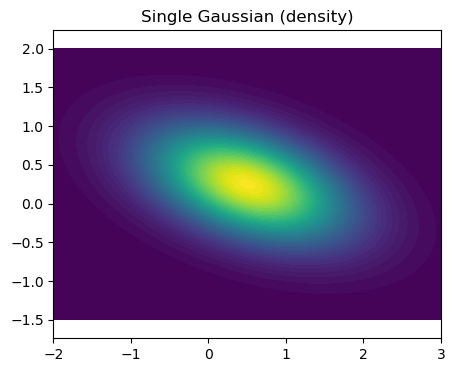

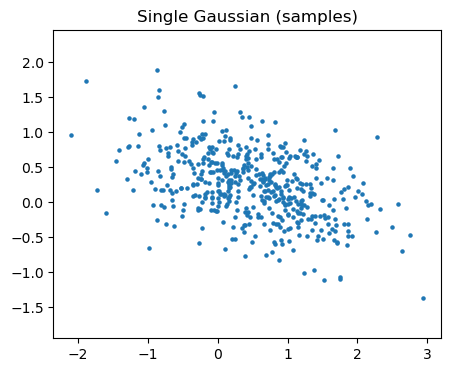

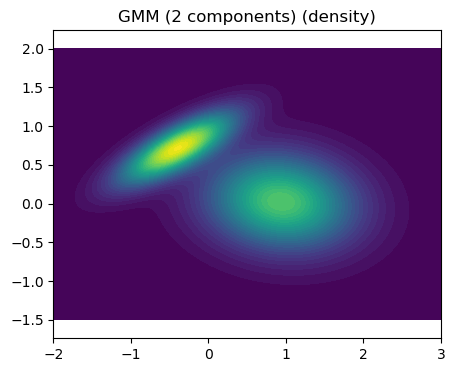

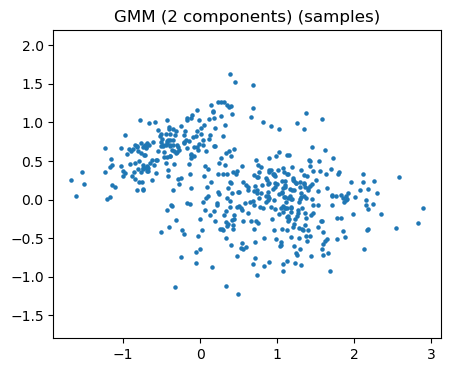

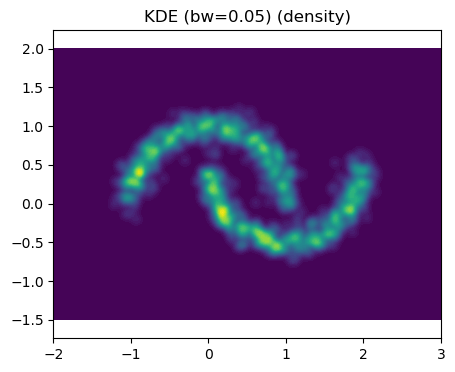

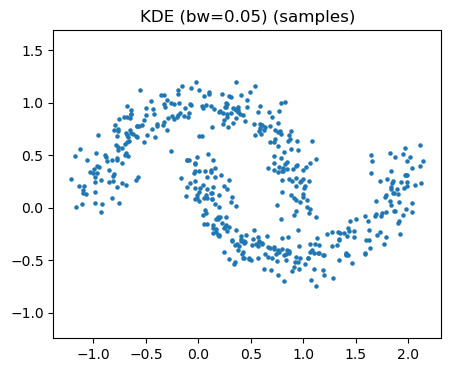

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from scipy.stats import multivariate_normal

# =========================================================
# 1. Model classes: Histogram2D, GaussianModel, GMM, KDE
# =========================================================

class Histogram2D:
    def __init__(self, bins=20, data_range=((-2, 3), (-1.5, 2))):
        self.bins = bins
        self.range = data_range

    def fit(self, X):
        self.hist, self.xedges, self.yedges = np.histogram2d(
            X[:, 0], X[:, 1], bins=self.bins, range=self.range, density=False
        )
        self.hist = self.hist / np.sum(self.hist)
        return self

    def sample(self, n_samples):
        probs = self.hist.flatten()
        probs = probs / np.sum(probs)
        indices = np.random.choice(len(probs), size=n_samples, p=probs)
        xi, yi = np.unravel_index(indices, self.hist.shape)
        x = np.random.uniform(self.xedges[xi], self.xedges[xi + 1])
        y = np.random.uniform(self.yedges[yi], self.yedges[yi + 1])
        return np.column_stack([x, y])

    def score_samples(self, X):
        xi = np.clip(np.searchsorted(self.xedges, X[:, 0]) - 1, 0, self.bins - 1)
        yi = np.clip(np.searchsorted(self.yedges, X[:, 1]) - 1, 0, self.bins - 1)
        probs = self.hist[xi, yi] / (
            (self.xedges[1] - self.xedges[0]) * (self.yedges[1] - self.yedges[0])
        )
        return np.log(probs + 1e-12)


class GaussianModel:
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.cov = np.cov(X, rowvar=False)
        return self

    def sample(self, n_samples):
        return np.random.multivariate_normal(self.mean, self.cov, size=n_samples)

    def score_samples(self, X):
        return multivariate_normal.logpdf(X, mean=self.mean, cov=self.cov)


class GMM:
    def __init__(self, n_components=2, max_iter=100, tol=1e-4):
        self.K = n_components
        self.max_iter = max_iter
        self.tol = tol

    def fit(self, X):
        n, d = X.shape

        rng = np.random.default_rng(0)
        self.means = X[rng.choice(n, self.K, replace=False)]
        self.covs = np.array([np.cov(X, rowvar=False)] * self.K)
        self.weights = np.ones(self.K) / self.K

        prev_ll = -np.inf
        for _ in range(self.max_iter):
            # E-step
            resp = np.zeros((n, self.K))
            for k in range(self.K):
                resp[:, k] = self.weights[k] * multivariate_normal.pdf(
                    X, mean=self.means[k], cov=self.covs[k]
                )

            p_x = np.sum(resp, axis=1) # This is p(x_n)
            ll = np.sum(np.log(p_x + 1e-12))

            resp = resp / (p_x[:, None] + 1e-12) # Use p_x to normalize
            Nk = resp.sum(axis=0)

            self.weights = Nk / n
            self.means = (resp.T @ X) / Nk[:, None]
            for k in range(self.K):
                diff = X - self.means[k]
                reg = 1e-6 * np.eye(d)
                self.covs[k] = (resp[:, k][:, None] * diff).T @ diff / Nk[k] + reg

            if abs(ll - prev_ll) < self.tol:
                break
            prev_ll = ll
        return self

    def sample(self, n_samples):
        ks = np.random.choice(self.K, size=n_samples, p=self.weights)
        samples = []
        for k in range(self.K):
            n_k = np.sum(ks == k)
            if n_k > 0:
                samples.append(
                    np.random.multivariate_normal(self.means[k], self.covs[k], size=n_k)
                )
        return np.vstack(samples)

    def score_samples(self, X):
        pdf = np.zeros(len(X))
        for k in range(self.K):
            pdf += self.weights[k] * multivariate_normal.pdf(
                X, mean=self.means[k], cov=self.covs[k]
            )
        return np.log(pdf + 1e-12)


class KDE:
    def __init__(self, bandwidth=0.1):
        self.bandwidth = bandwidth

    def fit(self, X):
        self.X = X
        return self

    def sample(self, n_samples):
        idx = np.random.randint(0, len(self.X), size=n_samples)
        noise = np.random.normal(scale=self.bandwidth, size=(n_samples, self.X.shape[1]))
        return self.X[idx] + noise

    def score_samples(self, X):
        dists = np.sum((X[:, None, :] - self.X[None, :, :]) ** 2, axis=2)
        kernel_vals = np.exp(-0.5 * dists / self.bandwidth**2)
        p = np.mean(kernel_vals, axis=1) / (2 * np.pi * self.bandwidth**2)
        return np.log(p + 1e-12)


# =========================================================
# 2. MMD metrics (SE + IMQ) — fully vectorized
# =========================================================

def kernel_se(X, Y, h=0.1):
    dists_sq = np.sum((X[:, None, :] - Y[None, :, :]) ** 2, axis=-1)
    return np.exp(-dists_sq / (h**2))


def kernel_imq(X, Y, h=1.0):
    dists_sq = np.sum((X[:, None, :] - Y[None, :, :]) ** 2, axis=-1)
    return 1.0 / np.sqrt(1 + dists_sq / (h**2))


def mmd2_unbiased(X, Y, kernel_fn):
    n = len(X)
    m = len(Y)
    Kxx = kernel_fn(X, X)
    Kyy = kernel_fn(Y, Y)
    Kxy = kernel_fn(X, Y)
    np.fill_diagonal(Kxx, 0)
    np.fill_diagonal(Kyy, 0)
    return (Kxx.sum() / (n * (n - 1))
            + Kyy.sum() / (m * (m - 1))
            - 2 * Kxy.mean())


# =========================================================
# 3. Evaluation and visualization
# =========================================================

def evaluate_model(model, model_name, param_name, param_values, X_train, X_test, kernel_fn):
    results = []
    for val in param_values:
        m = model(val)
        m.fit(X_train)
        samples = m.sample(len(X_test))
        mmd = mmd2_unbiased(X_test, samples, kernel_fn)
        results.append((model_name, param_name, val, mmd))
    return results


# =========================================================
# Example experiment
# =========================================================

X_train, _ = make_moons(n_samples=1000, noise=0.1)
X_test, _ = make_moons(n_samples=500, noise=0.1)

results = []
results += evaluate_model(lambda b: Histogram2D(bins=b),
                          'hist', 'bins', [10, 20, 40],
                          X_train, X_test, lambda A, B: kernel_se(A, B, h=0.1))

results += evaluate_model(lambda k: GMM(n_components=k),
                          'gmm', 'n_components', [1, 2, 5],
                          X_train, X_test, lambda A, B: kernel_se(A, B, h=0.1))

results += evaluate_model(lambda bw: KDE(bandwidth=bw),
                          'kde', 'bandwidth', [0.02, 0.05, 0.1],
                          X_train, X_test, lambda A, B: kernel_se(A, B, h=0.1))

gauss = GaussianModel().fit(X_train)
samples = gauss.sample(len(X_test))
results.append(('gauss', 'none', 0, mmd2_unbiased(X_test, samples, lambda A, B: kernel_se(A, B, h=0.1))))

# Convert to structured array
import pandas as pd
df = pd.DataFrame(results, columns=['model', 'param', 'value', 'mmd2'])
print(df)

# =========================================================
# 4. Visualize density and samples
# =========================================================

def plot_density(model, title):
    x = np.linspace(-2, 3, 200)
    y = np.linspace(-1.5, 2, 200)
    xx, yy = np.meshgrid(x, y)
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = np.exp(model.score_samples(grid)).reshape(xx.shape)

    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, zz, levels=50, cmap='viridis')
    plt.title(f"{title} (density)")
    plt.axis('equal')
    plt.show()

    samples = model.sample(500)
    plt.figure(figsize=(5, 4))
    plt.scatter(samples[:, 0], samples[:, 1], s=5)
    plt.title(f"{title} (samples)")
    plt.axis('equal')
    plt.show()

# Show some representative models
plot_density(Histogram2D(bins=20).fit(X_train), "Histogram (20 bins)")
plot_density(GaussianModel().fit(X_train), "Single Gaussian")
plot_density(GMM(n_components=2).fit(X_train), "GMM (2 components)")
plot_density(KDE(bandwidth=0.05).fit(X_train), "KDE (bw=0.05)")


<div style="color: green; font-weight:
bold">
In general, all of the model class implementation reproduce the result of sample solution for density estimation and sampling, and MMD^2 scores.

1. Histogram: Vectorized sampling process results the faster evaluation. Only difference with the sample solution is that this implementation does not smoothens the predicted probability density. 
2. Single Gaussian: Essentially the same as the sample solution. 
3. GMM: Initialization slightly differs.  Rather than k-means, the initial mean values chosen randomly and common initial covariance used. EM step is the same as the sample solution.  
4. KDE: Sampling process is vectorized and performs faster than the sample solution.

 </div> 

# Q2

Dataset shape: (1797, 64)
Number of classes: 10
Data range: [0.00, 16.00]
Training set: (1257, 64)
Test set: (540, 64)

1. Training DensityForest models:
   n_min=5... MMD² = 0.000185
   n_min=10... MMD² = 0.000170
   n_min=20... MMD² = 0.000209

2. Training Gaussian Mixture Models:
   n_components=5... MMD² = 0.000219
   n_components=10... MMD² = 0.000194
   n_components=20... MMD² = 0.000142

3. Training Kernel Density Estimators:
   bandwidth=1.0... MMD² = 0.000239
   bandwidth=2.0... MMD² = 0.000247
   bandwidth=5.0... MMD² = 0.000304

MMD² RESULTS SUMMARY
        model        param  value     mmd2
DensityForest        n_min    5.0 0.000185
DensityForest        n_min   10.0 0.000170
DensityForest        n_min   20.0 0.000209
          GMM n_components    5.0 0.000219
          GMM n_components   10.0 0.000194
          GMM n_components   20.0 0.000142
          KDE    bandwidth    1.0 0.000239
          KDE    bandwidth    2.0 0.000247
          KDE    bandwidth    5.0 0.000304

Be

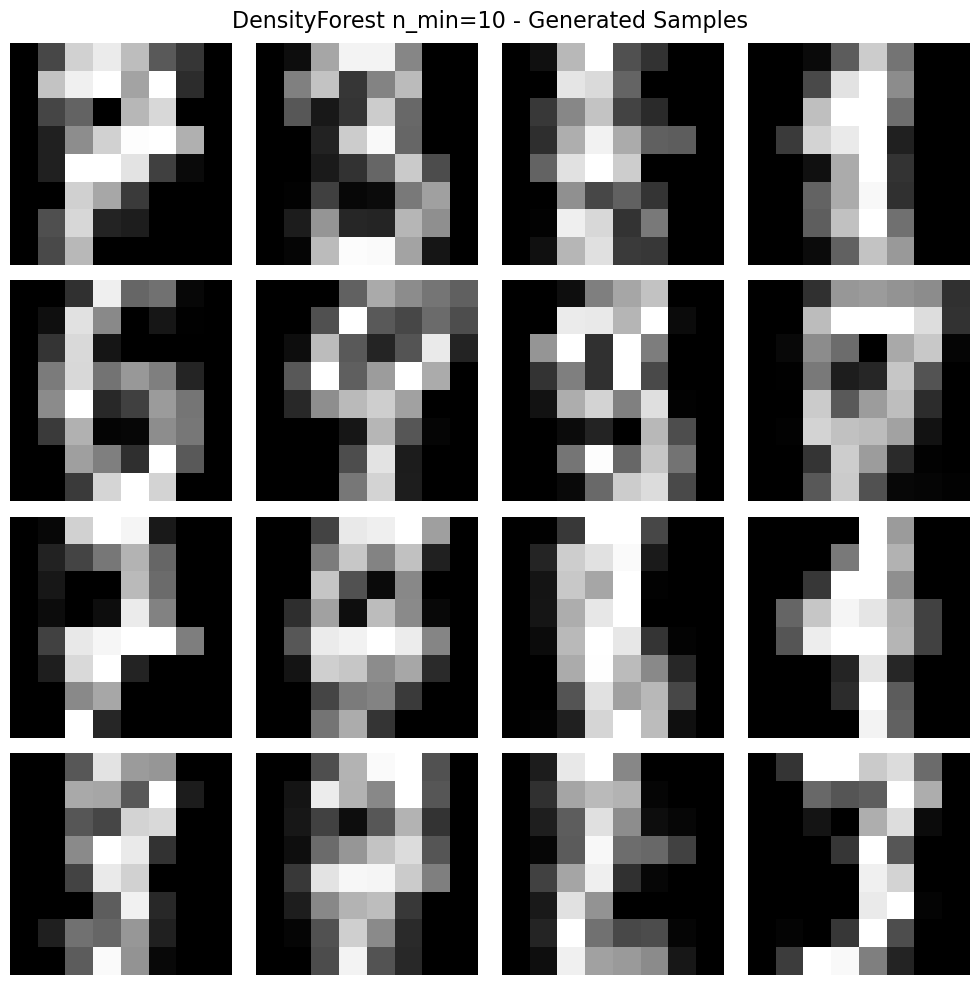

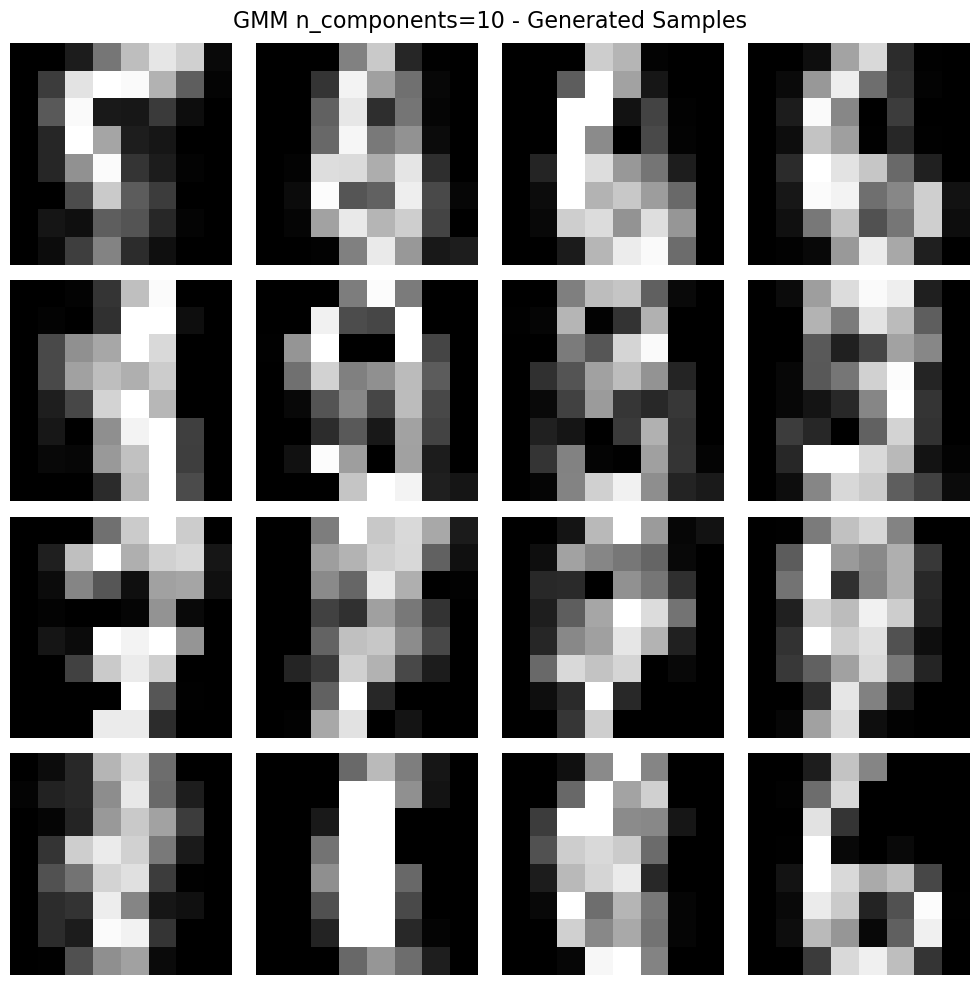

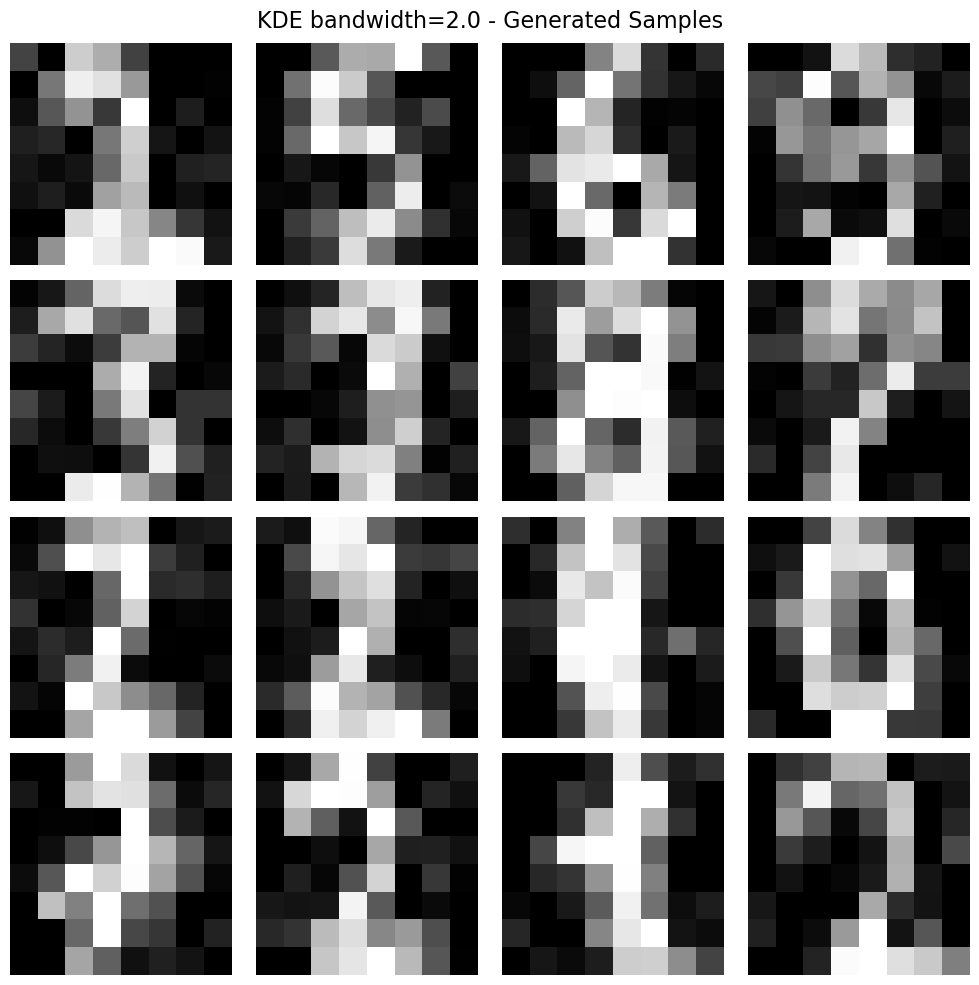


CLASSIFIER-BASED QUALITY CHECK

RandomForestClassifier trained on real digits:
  Training accuracy: 1.000
  Test accuracy: 0.967

Now testing on generated samples...

DensityForest (n_min=10):
  Generated 1000 samples
  Classes recognized: 10/10
  Distribution: {np.int64(0): np.int64(116), np.int64(1): np.int64(64), np.int64(2): np.int64(94), np.int64(3): np.int64(84), np.int64(4): np.int64(123), np.int64(5): np.int64(86), np.int64(6): np.int64(96), np.int64(7): np.int64(91), np.int64(8): np.int64(135), np.int64(9): np.int64(111)}
  Balance ratio (min/max): 0.474
  Assessment: poor

GMM (n_components=10):
  Generated 1000 samples
  Classes recognized: 10/10
  Distribution: {np.int64(0): np.int64(101), np.int64(1): np.int64(65), np.int64(2): np.int64(88), np.int64(3): np.int64(83), np.int64(4): np.int64(113), np.int64(5): np.int64(84), np.int64(6): np.int64(115), np.int64(7): np.int64(103), np.int64(8): np.int64(125), np.int64(9): np.int64(123)}
  Balance ratio (min/max): 0.520
  Asses

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
from density_forest import DensityForest

# =========================================================
# 1. MMD² metrics (reuse from Task 1)
# =========================================================

def kernel_se(X, Y, h=1.0):
    """Squared exponential kernel"""
    dists_sq = np.sum((X[:, None, :] - Y[None, :, :]) ** 2, axis=-1)
    return np.exp(-dists_sq / (h**2))

def kernel_imq(X, Y, h=1.0):
    """Inverse multi-quadratic kernel"""
    dists_sq = np.sum((X[:, None, :] - Y[None, :, :]) ** 2, axis=-1)
    return 1.0 / np.sqrt(1 + dists_sq / (h**2))

def mmd2_unbiased(X, Y, kernel_fn):
    """Unbiased MMD² estimator"""
    n = len(X)
    m = len(Y)
    Kxx = kernel_fn(X, X)
    Kyy = kernel_fn(Y, Y)
    Kxy = kernel_fn(X, Y)
    np.fill_diagonal(Kxx, 0)
    np.fill_diagonal(Kyy, 0)
    return (Kxx.sum() / (n * (n - 1))
            + Kyy.sum() / (m * (m - 1))
            - 2 * Kxy.mean())

# =========================================================
# 2. Load and prepare data
# =========================================================

digits = load_digits()
X_full = digits.data  # Shape: (1797, 64)
y_full = digits.target  # Labels 0-9

print(f"Dataset shape: {X_full.shape}")
print(f"Number of classes: {len(np.unique(y_full))}")
print(f"Data range: [{X_full.min():.2f}, {X_full.max():.2f}]")

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42, stratify=y_full
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# =========================================================
# 3. Train models and evaluate with MMD²
# =========================================================

results = []

# IMPORTANT: Scale bandwidth for 64D
# In 2D we used h=0.1, but distances are much larger in 64D
kernel_fn = lambda X, Y: kernel_se(X, Y, h=10.0)

# --- DensityForest ---
print("\n1. Training DensityForest models:")
for n_min in [5, 10, 20]:
    print(f"   n_min={n_min}...", end=" ")
    model = DensityForest(n_trees=10, n_min=n_min)
    model.fit(X_train)
    samples = model.sample(len(X_test))
    mmd = mmd2_unbiased(X_test, samples, kernel_fn)
    results.append(('DensityForest', 'n_min', n_min, mmd))
    print(f"MMD² = {mmd:.6f}")

# --- GMM ---
print("\n2. Training Gaussian Mixture Models:")
for n_components in [5, 10, 20]:
    print(f"   n_components={n_components}...", end=" ")
    model = GaussianMixture(n_components=n_components, random_state=42)
    model.fit(X_train)
    samples = model.sample(len(X_test))[0]  # Returns (samples, labels)
    mmd = mmd2_unbiased(X_test, samples, kernel_fn)
    results.append(('GMM', 'n_components', n_components, mmd))
    print(f"MMD² = {mmd:.6f}")

# --- KDE ---
print("\n3. Training Kernel Density Estimators:")
for bandwidth in [1.0, 2.0, 5.0]:
    print(f"   bandwidth={bandwidth}...", end=" ")
    model = KernelDensity(bandwidth=bandwidth, kernel='gaussian')
    model.fit(X_train)
    samples = model.sample(len(X_test), random_state=42)
    mmd = mmd2_unbiased(X_test, samples, kernel_fn)
    results.append(('KDE', 'bandwidth', bandwidth, mmd))
    print(f"MMD² = {mmd:.6f}")

# =========================================================
# 4. Display results summary
# =========================================================

df = pd.DataFrame(results, columns=['model', 'param', 'value', 'mmd2'])
print("\n" + "="*60)
print("MMD² RESULTS SUMMARY")
print("="*60)
print(df.to_string(index=False))
print()

# Find best hyperparameters
print("Best hyperparameters (lowest MMD²):")
for model_name in ['DensityForest', 'GMM', 'KDE']:
    best = df[df['model'] == model_name].nsmallest(1, 'mmd2')
    param = best['param'].values[0]
    value = best['value'].values[0]
    mmd_val = best['mmd2'].values[0]
    print(f"  {model_name}: {param}={value}, MMD²={mmd_val:.6f}")

# =========================================================
# 5. Visualize generated samples
# =========================================================

def visualize_samples(model, model_name, n_samples=16):
    """Visualize generated samples as 8x8 images"""
    samples = model.sample(n_samples)

    # Handle GMM which returns (samples, labels)
    if isinstance(samples, tuple):
        samples = samples[0]

    samples = np.clip(samples, 0, 16)  # Now this works!

    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle(f"{model_name} - Generated Samples", fontsize=16, y=0.98)

    for i, ax in enumerate(axes.flat):
        img = samples[i].reshape(8, 8)
        ax.imshow(img, cmap='gray', vmin=0, vmax=16)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("VISUALIZING GENERATED SAMPLES")
print("="*60)

# Train best models based on MMD²
best_df = DensityForest(n_trees=10, n_min=10)
best_df.fit(X_train)
visualize_samples(best_df, "DensityForest n_min=10")

best_gmm = GaussianMixture(n_components=10, random_state=42)
best_gmm.fit(X_train)
visualize_samples(best_gmm, "GMM n_components=10")

best_kde = KernelDensity(bandwidth=2.0, kernel='gaussian')
best_kde.fit(X_train)


visualize_samples(best_kde, "KDE bandwidth=2.0")

# =========================================================
# 6. Classifier-based quality check
# =========================================================

print("\n" + "="*60)
print("CLASSIFIER-BASED QUALITY CHECK")
print("="*60)

# Train classifier on real data
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)

print(f"\nRandomForestClassifier trained on real digits:")
print(f"  Training accuracy: {train_acc:.3f}")
print(f"  Test accuracy: {test_acc:.3f}")
print(f"\nNow testing on generated samples...\n")

def evaluate_with_classifier(model, model_name, n_samples=1000):
    """Check if classifier recognizes generated samples"""
    samples = model.sample(n_samples)
    if isinstance(samples, tuple):
        samples = samples[0]
    samples = np.clip(samples, 0, 16)

    predictions = clf.predict(samples)
    unique, counts = np.unique(predictions, return_counts=True)

    print(f"{model_name}:")
    print(f"  Generated {n_samples} samples")
    print(f"  Classes recognized: {len(unique)}/10")
    print(f"  Distribution: {dict(zip(unique, counts))}")

    if len(counts) > 1:
        balance_ratio = min(counts) / max(counts)
        print(f"  Balance ratio (min/max): {balance_ratio:.3f}")
        quality = "excellent" if balance_ratio > 0.7 else "good" if balance_ratio > 0.5 else "poor"
        print(f"  Assessment: {quality}")
    print()

evaluate_with_classifier(best_df, "DensityForest (n_min=10)", 1000)
evaluate_with_classifier(best_gmm, "GMM (n_components=10)", 1000)
evaluate_with_classifier(best_kde, "KDE (bandwidth=2.0)", 1000)

print("="*60)
print("EVALUATION COMPLETE")
print("="*60)
